In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fairlearn.datasets import fetch_acs_income

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
income = fetch_acs_income(as_frame=True)
print(type(income.frame))


<class 'pandas.core.frame.DataFrame'>


In [3]:
income_df = income.frame.copy()
income_df.to_csv("acs_income_raw.csv", index=False)

In [4]:
income_df

,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,PINCP
0,18.0,1.0,18.0,5.0,4720.0,13.0,17.0,21.0,2.0,2.0,1600.0
1,53.0,5.0,17.0,5.0,3605.0,18.0,16.0,40.0,1.0,1.0,10000.0
2,41.0,1.0,16.0,5.0,7330.0,1.0,17.0,40.0,1.0,1.0,24000.0
3,18.0,6.0,18.0,5.0,2722.0,1.0,17.0,2.0,2.0,1.0,180.0
4,21.0,5.0,19.0,5.0,3870.0,12.0,17.0,50.0,1.0,1.0,29000.0
...,...,...,...,...,...,...,...,...,...,...,...
1664495,39.0,6.0,16.0,5.0,6260.0,72.0,0.0,20.0,1.0,1.0,9600.0
1664496,38.0,6.0,14.0,5.0,4251.0,72.0,0.0,32.0,1.0,8.0,2400.0
1664497,37.0,1.0,19.0,3.0,7750.0,17.0,13.0,40.0,2.0,9.0,19700.0
1664498,47.0,1.0,16.0,1.0,8990.0,72.0,1.0,40.0,1.0,8.0,18700.0


In [5]:
income_df.shape

(1664500, 11)

In [6]:
income_df.head()

,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,PINCP
0,18.0,1.0,18.0,5.0,4720.0,13.0,17.0,21.0,2.0,2.0,1600.0
1,53.0,5.0,17.0,5.0,3605.0,18.0,16.0,40.0,1.0,1.0,10000.0
2,41.0,1.0,16.0,5.0,7330.0,1.0,17.0,40.0,1.0,1.0,24000.0
3,18.0,6.0,18.0,5.0,2722.0,1.0,17.0,2.0,2.0,1.0,180.0
4,21.0,5.0,19.0,5.0,3870.0,12.0,17.0,50.0,1.0,1.0,29000.0


In [7]:
income_df.columns

Index(['AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP', 'SEX',
       'RAC1P', 'PINCP'],
      dtype='object')

In [8]:
income_df.dtypes

AGEP     float64
COW      float64
SCHL     float64
MAR      float64
OCCP     float64
POBP     float64
RELP     float64
WKHP     float64
SEX      float64
RAC1P    float64
PINCP    float64
dtype: object

In [9]:
income_df.isna().sum()

AGEP     0
COW      0
SCHL     0
MAR      0
OCCP     0
POBP     0
RELP     0
WKHP     0
SEX      0
RAC1P    0
PINCP    0
dtype: int64

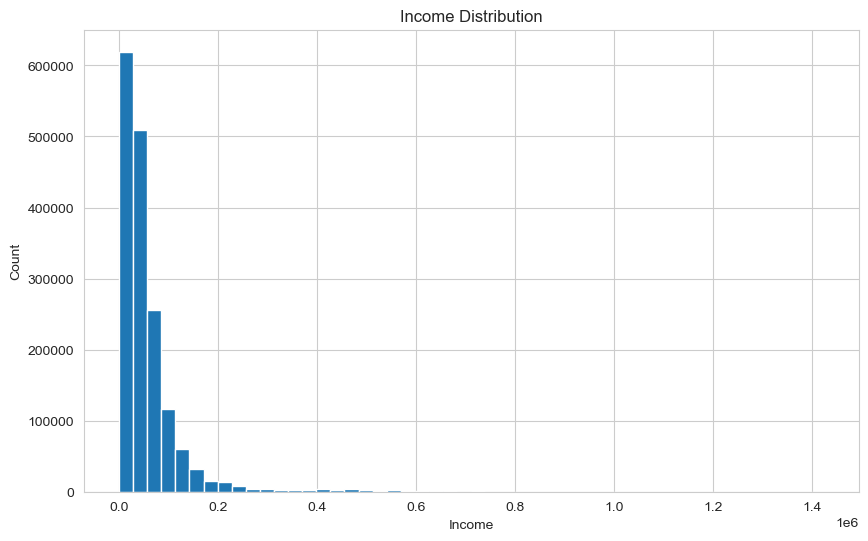

In [10]:
plt.hist(income_df['PINCP'],bins = 50)
plt.xlabel("Income")
plt.ylabel("Count")
plt.title('Income Distribution')
plt.show()


In [11]:
mean_income_by_gender = income_df.groupby("SEX")["PINCP"].mean()
mean_income_by_gender

SEX
1.0    67762.889827
2.0    44605.279921
Name: PINCP, dtype: float64

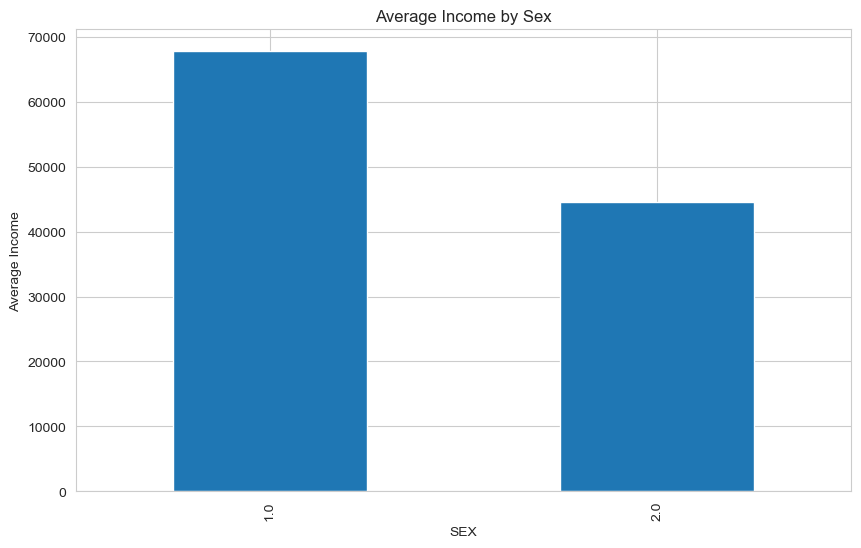

In [12]:
mean_income_by_gender.plot(kind='bar')
plt.ylabel('Average Income')
plt.title('Average Income by Sex')
plt.show()

In [13]:
# there are some very high earners in SEX=1 pulling the average way up --> median gives a better idea because of the skew 
median_income_by_gender = income_df.groupby("SEX")["PINCP"].median()
median_income_by_gender

SEX
1.0    45000.0
2.0    32000.0
Name: PINCP, dtype: float64

In [14]:
# Race code 1.0 ==> White alone

income_df['RAC1P'].value_counts()


RAC1P
1.0    1298126
2.0     147573
6.0      96399
8.0      62877
9.0      41815
3.0      11887
7.0       2813
5.0       2104
4.0        906
Name: count, dtype: int64

In [33]:
income_by_race  = income_df.groupby('RAC1P')['PINCP'].median()
income_by_race

RAC1P
1.0    40000.0
2.0    30000.0
3.0    29000.0
4.0    22450.0
5.0    26450.0
6.0    45000.0
7.0    30700.0
8.0    26500.0
9.0    30000.0
Name: PINCP, dtype: float64

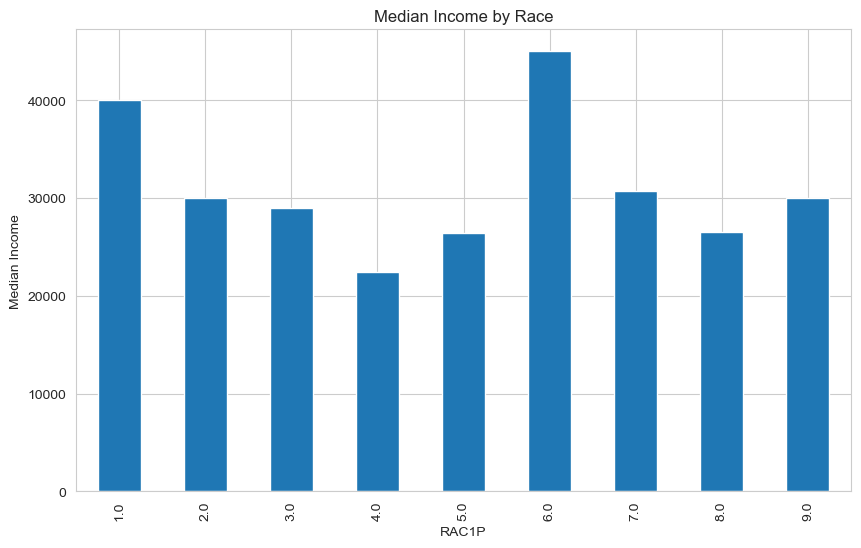

In [34]:
# 6.0 indicates asian  ==> Asian tend to earn more ; least ==> 4.0 = Alaska Native 
income_df.groupby('RAC1P')['PINCP'].median().plot(kind='bar')
plt.ylabel('Median Income')
plt.title('Median Income by Race')
plt.show()

In [35]:
income_df.groupby(['SEX', 'RAC1P'])['PINCP'].median()


SEX  RAC1P
1.0  1.0      49800.0
     2.0      30100.0
     3.0      32000.0
     4.0      21330.0
     5.0      30000.0
     6.0      53500.0
     7.0      35000.0
     8.0      30000.0
     9.0      35000.0
2.0  1.0      33400.0
     2.0      28800.0
     3.0      25000.0
     4.0      24000.0
     5.0      23600.0
     6.0      38000.0
     7.0      29400.0
     8.0      22400.0
     9.0      27000.0
Name: PINCP, dtype: float64

In [42]:
income_by_age = income_df.groupby("AGEP")["PINCP"].median()
income_by_age

AGEP
17.0     2300.0
18.0     3500.0
19.0     5000.0
20.0     8000.0
21.0    10000.0
         ...   
92.0    36200.0
93.0    45000.0
94.0    38500.0
95.0    40975.0
96.0    31700.0
Name: PINCP, Length: 80, dtype: float64

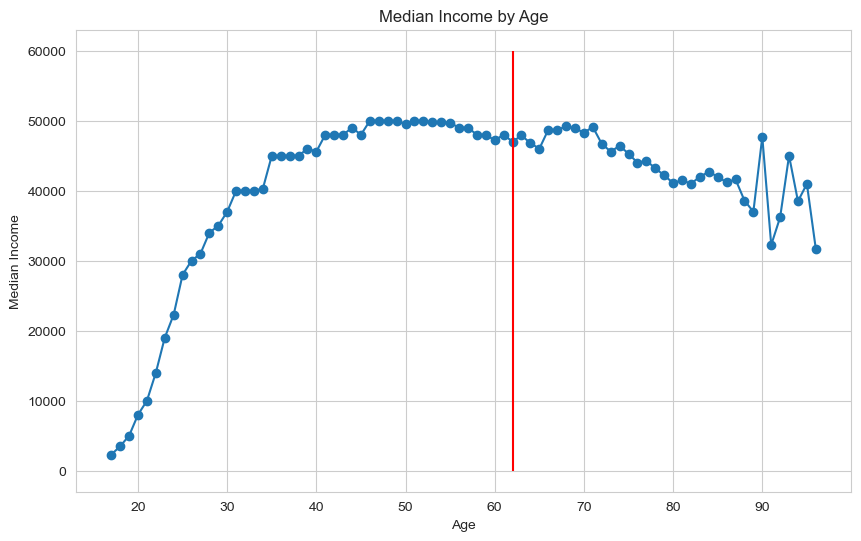

In [47]:
# weird --> why does incme keep increasing even after average US retirement age(62)??  --> 
# "Survivor" Bias in the Workforce : wealthy people tend to keep their positions past retirement age 
# ; investments ; 
# jumps in data suggest less people in older ages 
plt.plot(income_by_age.index, income_by_age.values, marker='o')
plt.xlabel("Age")
plt.ylabel("Median Income")
plt.title("Median Income by Age")
plt.grid(True)
plt.vlines(x=62, ymin=0, ymax=60000, colors='r', linestyles='solid') # average age of retirement
plt.show()

In [73]:
pivot_race_sex = income_df.pivot_table(values='PINCP', index='RAC1P', columns='SEX', aggfunc='median')


In [74]:
pivot_race_sex

SEX,1.0,2.0
RAC1P,,
1.0,49800.0,33400.0
2.0,30100.0,28800.0
3.0,32000.0,25000.0
4.0,21330.0,24000.0
5.0,30000.0,23600.0
6.0,53500.0,38000.0
7.0,35000.0,29400.0
8.0,30000.0,22400.0
9.0,35000.0,27000.0


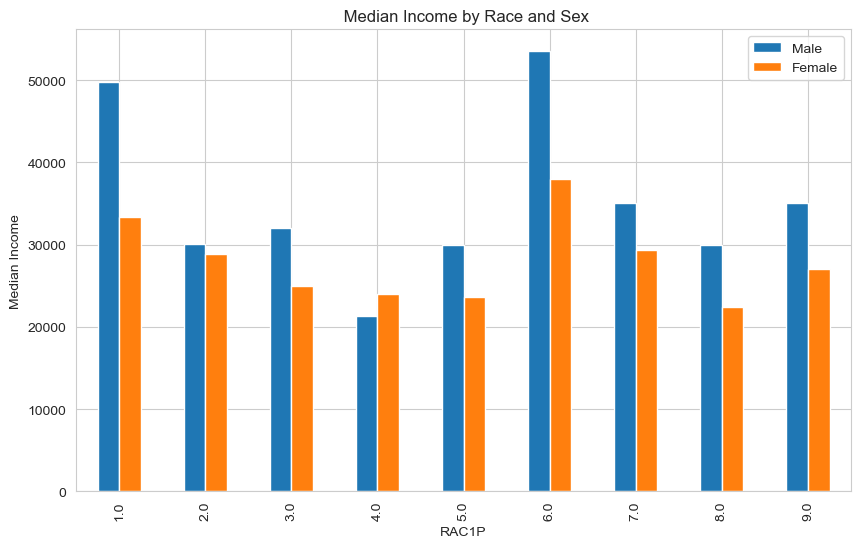

In [75]:
# even within the backgrounds that make a lower income -- women are ofen making even lower ; certain race + gender combos are worse off 
pivot.plot(kind='bar', figsize=(10,6))
plt.ylabel('Median Income')
plt.title(' Median Income by Race and Sex')
plt.legend(['Male', 'Female'])  
plt.show()

## Next: ##
Try other combinations:

Income by age?
Income by education level?
How do missing values look?
Anything weird or surprising?

 

In [51]:
income_df.columns

Index(['AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP', 'SEX',
       'RAC1P', 'PINCP'],
      dtype='object')

In [52]:
income_by_age = income_df.groupby("AGEP")["PINCP"].mean()
income_by_age

AGEP
17.0     4264.972672
18.0     6170.738336
19.0     8422.694238
20.0    11733.360741
21.0    14087.777703
            ...     
92.0    55350.242424
93.0    67163.623188
94.0    70031.244444
95.0    58460.340909
96.0    49777.142857
Name: PINCP, Length: 80, dtype: float64

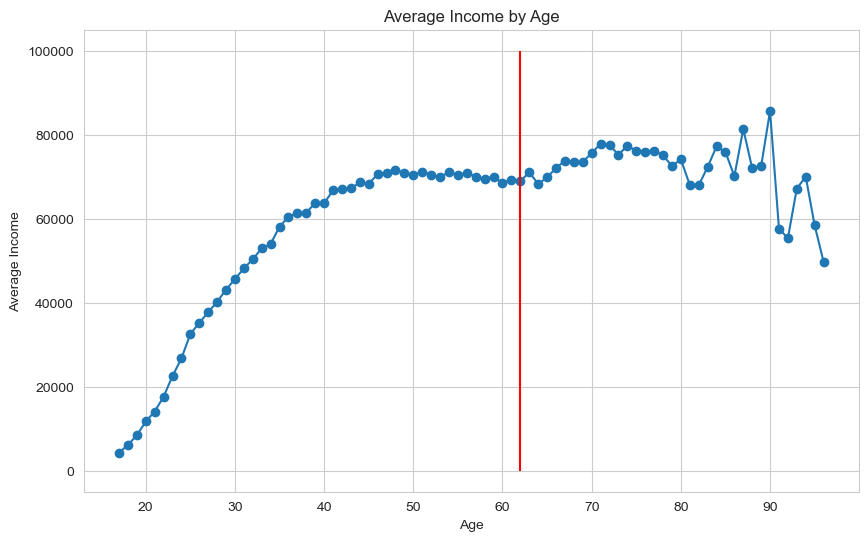

In [23]:
# weird --> why does incme keep increasing even after average US retirement age(62)??  --> 
# "Survivor" Bias in the Workforce : wealthy people tend to keep their positions past retirement age 
# ; investments ; 
# jumps in data suggest less people in older ages 
plt.plot(income_by_age.index, income_by_age.values, marker='o')
plt.xlabel("Age")
plt.ylabel("Average Income")
plt.title("Average Income by Age")
plt.grid(True)
plt.vlines(x=62, ymin=0, ymax=100000, colors='r', linestyles='solid') # average age of retirement
plt.show()

## Average income by age and gender 

In [64]:
income_by_age_sex = income_df.groupby(["AGEP", "SEX"])["PINCP"].median().reset_index()
income_by_age_sex

,AGEP,SEX,PINCP
0,17.0,1.0,2400.0
1,17.0,2.0,2200.0
2,18.0,1.0,4000.0
3,18.0,2.0,3300.0
4,19.0,1.0,5700.0
...,...,...,...
155,94.0,2.0,32530.0
156,95.0,1.0,47100.0
157,95.0,2.0,32495.0
158,96.0,1.0,38200.0


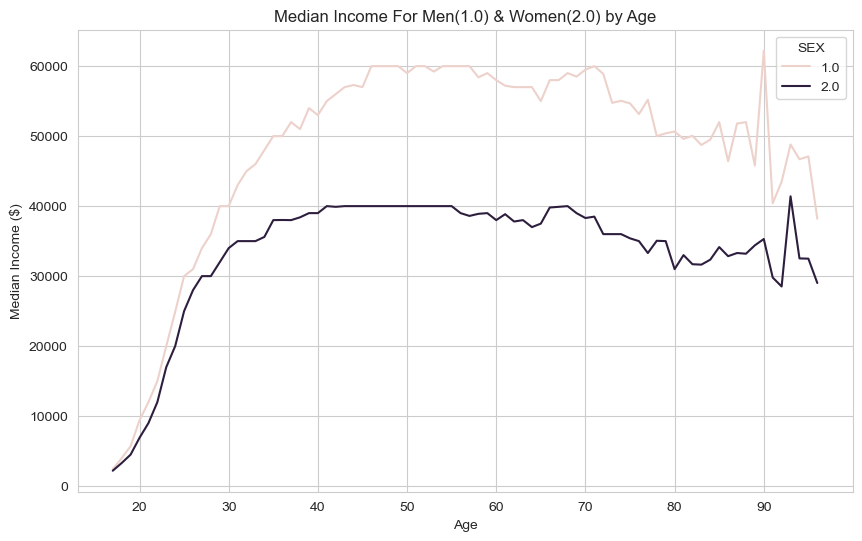

In [66]:

sns.lineplot(data=income_by_age_sex, x='AGEP', y='PINCP', hue='SEX')
plt.xlabel('Age')
plt.ylabel('Median Income ($)')
plt.title("Median Income For Men(1.0) & Women(2.0) by Age")
plt.show()

In [80]:
income_by_edu_sex = income_df.groupby(["SCHL", "SEX"])["PINCP"].median().reset_index()
income_by_edu_sex

,SCHL,SEX,PINCP
0,1.0,1.0,29100.0
1,1.0,2.0,20000.0
2,2.0,1.0,33000.0
3,2.0,2.0,25000.0
4,3.0,1.0,30000.0
5,3.0,2.0,20100.0
6,4.0,1.0,25000.0
7,4.0,2.0,18000.0
8,5.0,1.0,25000.0
9,5.0,2.0,17700.0


In [81]:
pivot_edu_sex = income_df.pivot_table(values='PINCP', index='SCHL', columns='SEX', aggfunc='median')
pivot_edu_sex

SEX,1.0,2.0
SCHL,,
1.0,29100.0,20000.0
2.0,33000.0,25000.0
3.0,30000.0,20100.0
4.0,25000.0,18000.0
5.0,25000.0,17700.0
6.0,26550.0,17000.0
7.0,27000.0,18000.0
8.0,28000.0,19000.0
9.0,28000.0,18000.0


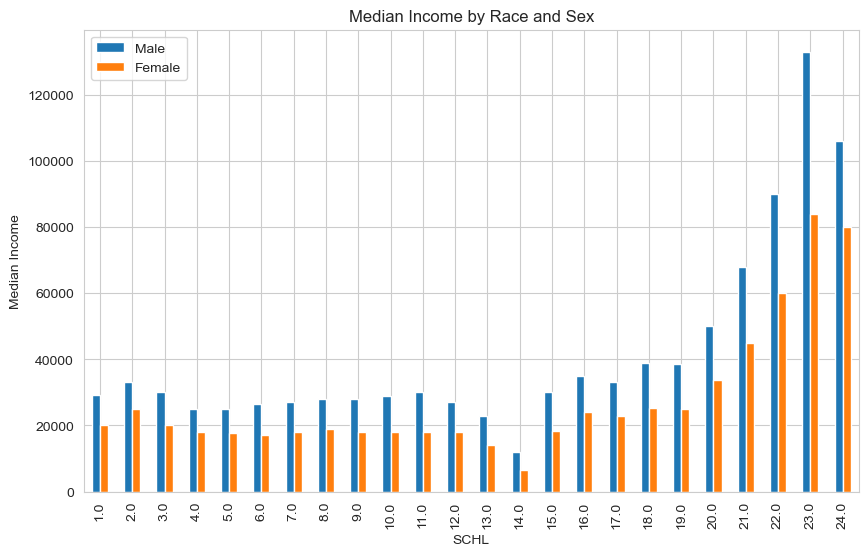

In [78]:
pivot_edu_sex.plot(kind='bar', figsize=(10,6))
plt.ylabel('Median Income')
plt.title('Median Income by Race and Sex')
plt.legend(['Male', 'Female'])  
plt.show()

In [89]:
top_occupations = income_df['OCCP'].value_counts().head(50).index

# Filter to only those occupations
top_occp_df = income_df[income_df['OCCP'].isin(top_occupations)]




In [90]:
pivot_occp_sex = income_df.pivot_table(values='PINCP', index='OCCP', columns='SEX', aggfunc='median')
pivot_occp_sex

SEX,1.0,2.0
OCCP,,
10.0,150700.0,100000.0
20.0,80000.0,59000.0
40.0,76000.0,50765.0
51.0,90000.0,62000.0
52.0,105000.0,70000.0
...,...,...
9760.0,40000.0,30000.0
9800.0,68010.0,71500.0
9810.0,65000.0,59000.0


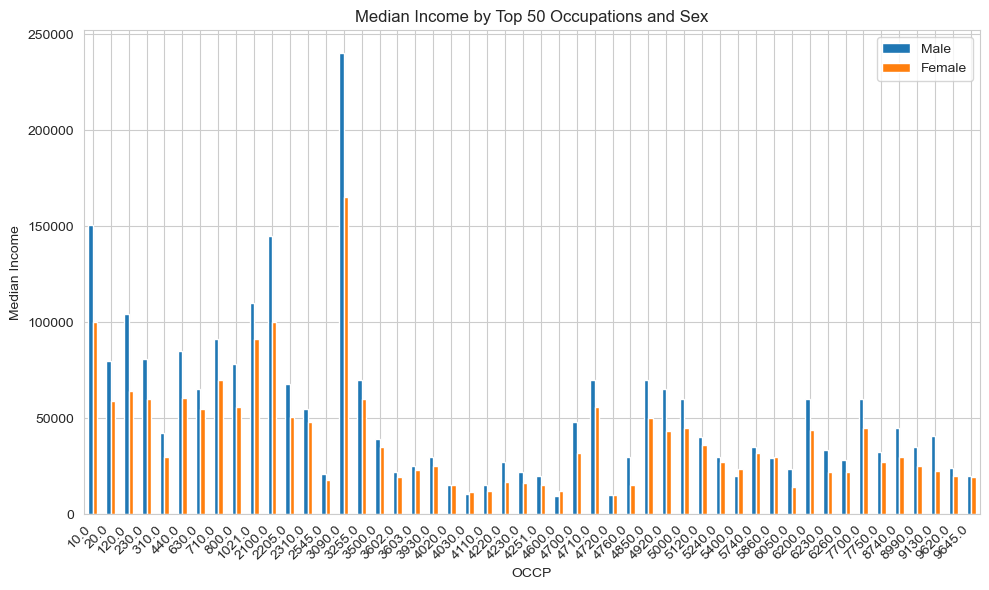

In [93]:
# Now plot
pivot_occp_sex = top_occp_df.pivot_table(values='PINCP', index='OCCP', columns='SEX', aggfunc='median')
pivot_occp_sex.plot(kind='bar')
plt.ylabel('Median Income')
plt.title('Median Income by Top 50 Occupations and Sex')
plt.legend(['Male', 'Female'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Next Plan of Action
1. What were your most interesting findings?

What surprised you?
What confirmed what you expected?
What made you go "whoa, that's a big difference"?

2. What patterns jumped out?

How big were the gender gaps?
What about racial disparities?
Did anything compound when you looked at intersections?
Any age or education patterns?

3. What questions do you have now?

Anything confusing?
Anything you want to dig deeper on?

Based on what you found, we'll:
Pick 2-3 specific focus areas for deeper analysis. For example:

"The gender pay gap and how it varies by race"
"Intersectional income disparities"
"How education affects the gender gap"

Then you'll create a new notebook (bias_analysis.ipynb) where you:

Do focused, deeper analysis on those specific questions
Create polished visualizations
Document your findings
Build your argument

So tell me:
What did you find that was most interesting/surprising/concerning?
Share 2-3 things that stood out to you, and we'll figure out what to focus on for the actual project.